# COMBINED DATA FIGURE 

In [1]:
from pynwb import NWBHDF5IO
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np 
import os
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde

# Set working directory to test this out locally 
os.chdir('/Users/nicole.burke/OneDrive - Child Mind Institute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data')
print(os.getcwd())

### Custom functions for script 
def descr_stats(df, column_name):
    stats = df[column_name].agg(
        mean='mean',
        min='min',
        max='max',
        std='std'
    )
    print(f"Summary stats for column: {column_name}")
    print(stats)

    return stats

/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data


## The *Present* DS1

In [2]:
#### Read in data 
present_df = pd.read_csv('present_ds1_df.csv')
present_df = present_df.iloc[:, 1:]
print(present_df.head())
print(present_df.shape)

   x_corr_pixels  y_corr_pixels     times      subjectID
0          564.2          631.6 -1.122725  sub-A00010201
1          564.3          630.9 -1.117170  sub-A00010201
2          564.5          629.8 -1.111614  sub-A00010201
3          564.7          628.0 -1.106058  sub-A00010201
4          564.3          628.4 -1.100503  sub-A00010201
(7500629, 4)


In [3]:
### descriptive stats 
present_number_subjects = len(present_df['subjectID'].unique())
print(f"Number of subjects in PRESENT: {present_number_subjects}")

xx = descr_stats(present_df, 'x_corr_pixels')
print("*"*10)
yy = descr_stats(present_df, 'y_corr_pixels')

Number of subjects in PRESENT: 192
Summary stats for column: x_corr_pixels
mean     653.117197
min    -3160.400000
max     3147.400000
std       82.660693
Name: x_corr_pixels, dtype: float64
**********
Summary stats for column: y_corr_pixels
mean     410.297653
min    -3263.300000
max     3275.800000
std      127.219302
Name: y_corr_pixels, dtype: float64


In [4]:
records = []

for subj, grp in present_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["x_corr_pixels"].values
    y     = grp["y_corr_pixels"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["x_corr_pixels", "y_corr_pixels"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: PRESENT data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

Summary stats for column: sample_rate_hz
mean    178.313542
min      55.500000
max     180.000000
std      13.167174
Name: sample_rate_hz, dtype: float64
Summary stats for column: x_min
mean      82.620833
min    -3160.400000
max      622.100000
std      430.811558
Name: x_min, dtype: float64
Summary stats for column: y_min
mean    -182.952083
min    -3263.300000
max      814.700000
std      791.559343
Name: y_min, dtype: float64
unique sampling rate in sample: [180.0, 177.8, 179.6, 179.5, 126.1, 165.6, 179.8, 57.4, 176.7, 55.5, 179.4]


### The *Present* FILTERED

In [5]:
### present
# x
present_mean_x = present_df['x_corr_pixels'].mean()
present_sd_x = present_df['x_corr_pixels'].std()
print(f"present x_corr mean: {present_mean_x} and std: {present_sd_x}")
present_upper_x = present_mean_x + (present_sd_x*2.5)
present_lower_x = present_mean_x - (present_sd_x*2.5)
print(f"present x_corr upper: {present_upper_x} and lower: {present_lower_x}")
print(f"present x_corr min x: {present_df['x_corr_pixels'].min()} and max x: {present_df['x_corr_pixels'].max()}")
print(f"present number of samples: {len(present_df)}")

# filter out oultiers 
present_df_filtered = present_df[
    (present_df['x_corr_pixels'] <= present_upper_x) &
    (present_df['x_corr_pixels'] >= present_lower_x)
]
print(f"Filter present mean x: {present_df_filtered['x_corr_pixels'].mean()}, x_min: {present_df_filtered['x_corr_pixels'].min()}, x_max: {present_df_filtered['x_corr_pixels'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")

print("*"*50)

# y 
present_mean_y = present_df['y_corr_pixels'].mean()
present_sd_y = present_df['y_corr_pixels'].std()
print(f"present y_corr mean: {present_mean_y} and std: {present_sd_y}")
present_upper_y = present_mean_y + (present_sd_y*2.5)
present_lower_y = present_mean_y - (present_sd_y*2.5)
print(f"present y_corr upper: {present_upper_y} and lower: {present_lower_y}")
print(f"present y_corr min y: {present_df['y_corr_pixels'].min()} and max y: {present_df['y_corr_pixels'].max()}")

# filter out outliers 
present_df_filtered = present_df_filtered[
    (present_df_filtered['y_corr_pixels'] <= present_upper_y) &
    (present_df_filtered['y_corr_pixels'] >= present_lower_y)
]
print(f"Filtered present mean y: {present_df_filtered['y_corr_pixels'].mean()}, y_min: {present_df_filtered['y_corr_pixels'].min()}, y_max: {present_df_filtered['y_corr_pixels'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")
print(f"Filter present number of subjects: {len(present_df['subjectID'].unique())}")

present x_corr mean: 653.1171967844298 and std: 82.66069334043692
present x_corr upper: 859.768930135522 and lower: 446.4654634333375
present x_corr min x: -3160.4 and max x: 3147.4
present number of samples: 7500629
Filter present mean x: 654.9725570006368, x_min: 446.5, x_max: 859.7
Filter present number of samples lost: 136106
**************************************************
present y_corr mean: 410.2976534234662 and std: 127.21930195190917
present y_corr upper: 728.3459083032392 and lower: 92.2493985436933
present y_corr min y: -3263.3 and max y: 3275.8
Filtered present mean y: 405.2632955712474, y_min: 92.3, y_max: 728.3
Filter present number of samples lost: 285279
Filter present number of subjects: 192


### The *Present* Plot RAW data 

In [ ]:
plt.plot(present_df['times'], present_df['x_corr_pixels'])
plt.title("RAW Present: x_corr_pixels x Time")
plt.show()

plt.plot(present_df_filtered['times'], present_df_filtered['x_corr_pixels'])
plt.ylim(-500,1500)
plt.title("FILTERED Present: x_corr_pixels x Time")
plt.show()


### The *Present* STANDARIZED

In [6]:
# present 
present_df_standard = present_df_filtered
x_min_present = present_df_filtered['x_corr_pixels'].min()
x_max_present = present_df_filtered['x_corr_pixels'].max()
present_df_standard['x_norm'] = (present_df_standard['x_corr_pixels'] - x_min_present) / (x_max_present - x_min_present)
x_norm = descr_stats(present_df_standard, 'x_norm')

print("*"*50)

y_min_present = present_df_filtered['y_corr_pixels'].min()
y_max_present = present_df_filtered['y_corr_pixels'].max()
present_df_standard['y_norm'] = (present_df_standard['y_corr_pixels'] - y_min_present) / (y_max_present - y_min_present)
y_norm = descr_stats(present_df_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.503631
min     0.000000
max     1.000000
std     0.147825
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.492081
min     0.000000
max     1.000000
std     0.159880
Name: y_norm, dtype: float64


## The *Present* DS2

In [7]:
#### Read in data 
present_df2 = pd.read_csv('present_ds2_right_eye_df.csv')
present_df2 = present_df2.iloc[:, 1:]
print(present_df2.head())
print(present_df2.shape)

    rightEyeX   rightEyeY     times      subjectID
0  629.099976  518.599976 -1.367178  sub-A00008326
1  629.700012  519.400024 -1.365070  sub-A00008326
2  629.700012  519.400024 -1.363065  sub-A00008326
3  627.400024  524.000000 -1.361112  sub-A00008326
4  623.799988  529.200012 -1.359141  sub-A00008326
(12527062, 4)


In [8]:
### descriptive stats 
present_number_subjects = len(present_df2['subjectID'].unique())
print(f"Number of subjects in PRESENT: {present_number_subjects}")

xx = descr_stats(present_df2, 'rightEyeX')
print("*"*10)
yy = descr_stats(present_df2, 'rightEyeY')

Number of subjects in PRESENT: 115
Summary stats for column: rightEyeX
mean    -1927.916931
min    -32768.000000
max      2559.699951
std      8921.628328
Name: rightEyeX, dtype: float64
**********
Summary stats for column: rightEyeY
mean    -2058.005685
min    -32768.000000
max      2046.800049
std      8882.972553
Name: rightEyeY, dtype: float64


In [9]:
records = []

for subj, grp in present_df2.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["rightEyeX"].values
    y     = grp["rightEyeY"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["rightEyeX", "rightEyeY"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: PRESENT data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

Summary stats for column: sample_rate_hz
mean    499.873043
min     359.100000
max     520.900000
std      20.794269
Name: sample_rate_hz, dtype: float64
unique sampling rate in sample: [505.3, 502.9, 503.3, 517.2, 497.7, 506.6, 508.2, 504.6, 497.3, 503.5, 505.5, 504.9, 505.9, 501.4, 500.8, 497.1, 501.1, 507.0, 505.2, 509.3, 505.8, 508.5, 504.1, 485.6, 500.0, 499.0, 502.8, 504.4, 503.0, 501.2, 498.9, 511.2, 502.7, 503.7, 501.5, 503.6, 520.9, 420.1, 497.0, 502.2, 503.2, 501.8, 504.7, 501.9, 499.6, 359.1, 507.8, 503.9, 505.0, 506.3, 512.3, 361.7, 506.4, 506.9, 501.3, 503.8, 499.7, 501.6, 485.2, 494.4, 496.3, 504.2, 507.4, 500.9, 506.7, 507.7, 502.5, 495.0, 502.6, 490.0, 498.7, 484.7, 506.0, 500.1, 507.2, 508.8, 504.0, 501.7, 502.1]


### The *Present* DS2 FILTERED 

In [10]:
### present
# x
present_mean_x = present_df2['rightEyeX'].mean()
present_sd_x = present_df2['rightEyeX'].std()
print(f"present x_corr mean: {present_mean_x} and std: {present_sd_x}")
present_upper_x = present_mean_x + (present_sd_x*2.5)
present_lower_x = present_mean_x - (present_sd_x*2.5)
print(f"present x_corr upper: {present_upper_x} and lower: {present_lower_x}")
print(f"present x_corr min x: {present_df2['rightEyeX'].min()} and max x: {present_df2['rightEyeX'].max()}")
print(f"present number of samples: {len(present_df2)}")

# filter out oultiers 
present_df2_filtered = present_df2[
    (present_df2['rightEyeX'] <= present_upper_x) &
    (present_df2['rightEyeX'] >= present_lower_x)
]
print(f"Filter present mean x: {present_df2_filtered['rightEyeX'].mean()}, x_min: {present_df2_filtered['rightEyeX'].min()}, x_max: {present_df2_filtered['rightEyeX'].max()}")
print(f"Filter present number of samples lost: {len(present_df2)-len(present_df2_filtered)}")

print("*"*50)

# y 
present_mean_y = present_df2['rightEyeY'].mean()
present_sd_y = present_df2['rightEyeY'].std()
print(f"present y_corr mean: {present_mean_y} and std: {present_sd_y}")
present_upper_y = present_mean_y + (present_sd_y*2.5)
present_lower_y = present_mean_y - (present_sd_y*2.5)
print(f"present y_corr upper: {present_upper_y} and lower: {present_lower_y}")
print(f"present y_corr min y: {present_df2['rightEyeY'].min()} and max y: {present_df2['rightEyeY'].max()}")

# filter out outliers 
present_df2_filtered = present_df2_filtered[
    (present_df2_filtered['rightEyeY'] <= present_upper_y) &
    (present_df2_filtered['rightEyeY'] >= present_lower_y)
]
print(f"Filtered present mean y: {present_df2_filtered['rightEyeY'].mean()}, y_min: {present_df2_filtered['rightEyeY'].min()}, y_max: {present_df2_filtered['rightEyeY'].max()}")
print(f"Filter present number of samples lost: {len(present_df2)-len(present_df2_filtered)}")
print(f"Filter present number of subjects: {len(present_df2['subjectID'].unique())}")

present x_corr mean: -1927.9169310710067 and std: 8921.628328148188
present x_corr upper: 20376.153889299465 and lower: -24231.987751441477
present x_corr min x: -32768.0 and max x: 2559.699951171875
present number of samples: 12527062
Filter present mean x: 651.4910385655261, x_min: -1279.5999755859375, x_max: 2559.699951171875
Filter present number of samples lost: 966873
**************************************************
present y_corr mean: -2058.0056852035495 and std: 8882.972552968735
present y_corr upper: 20149.42569721829 and lower: -24265.437067625386
present y_corr min y: -32768.0 and max y: 2046.800048828125
Filtered present mean y: 510.52189969408386, y_min: -1023.7000122070312, y_max: 2046.800048828125
Filter present number of samples lost: 966873
Filter present number of subjects: 115


### The *Present* DS2 STANDARIZED 

In [11]:
# present 
present_df2_standard = present_df2_filtered
x_min_present = present_df2_filtered['rightEyeX'].min()
x_max_present = present_df2_filtered['rightEyeX'].max()
present_df2_standard['x_norm'] = (present_df2_standard['rightEyeX'] - x_min_present) / (x_max_present - x_min_present)
x_norm = descr_stats(present_df2_standard, 'x_norm')

print("*"*50)

y_min_present = present_df2_filtered['rightEyeY'].min()
y_max_present = present_df2_filtered['rightEyeY'].max()
present_df2_standard['y_norm'] = (present_df2_standard['rightEyeY'] - y_min_present) / (y_max_present - y_min_present)
y_norm = descr_stats(present_df2_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.502980
min     0.000000
max     1.000000
std     0.058335
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.499665
min     0.000000
max     1.000000
std     0.056453
Name: y_norm, dtype: float64


## Combine *Present* DS1 and DS2

In [16]:
cols = ['times', 'subjectID', 'x_norm', 'y_norm']
present_df_merge = present_df_standard[cols]
present_df2_merge = present_df2_standard[cols]

present_combined_df = pd.concat([present_df_merge, present_df2_merge])

In [40]:
descr_stats(present_combined_df, 'times')

Summary stats for column: times
mean    107.080885
min     -40.612349
max     378.375677
std      63.781839
Name: times, dtype: float64


mean    107.080885
min     -40.612349
max     378.375677
std      63.781839
Name: times, dtype: float64

## The *Present* PLOT

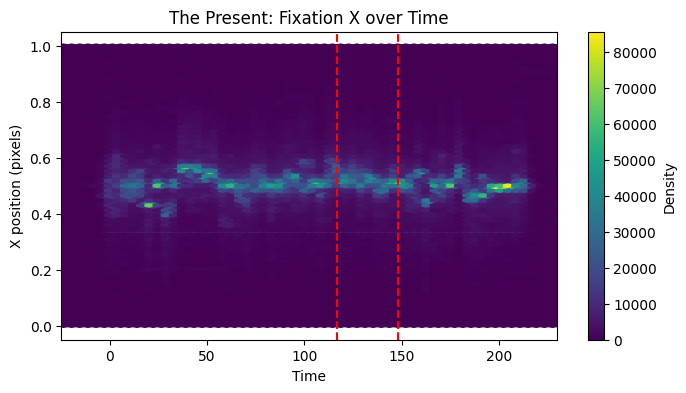

In [44]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_combined_df['times'],
    present_combined_df['x_norm'],
    gridsize=100,
)

# Add lines: 1:57 and 2:28
line_times = [117, 148]

# Add vertical dashed red lines
for t in line_times:
    plt.axvline(x=t, color='red', linestyle='--')

plt.colorbar(label='Density')
plt.xlim(-25, 230)
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('The Present: Fixation X over Time')

plt.show()

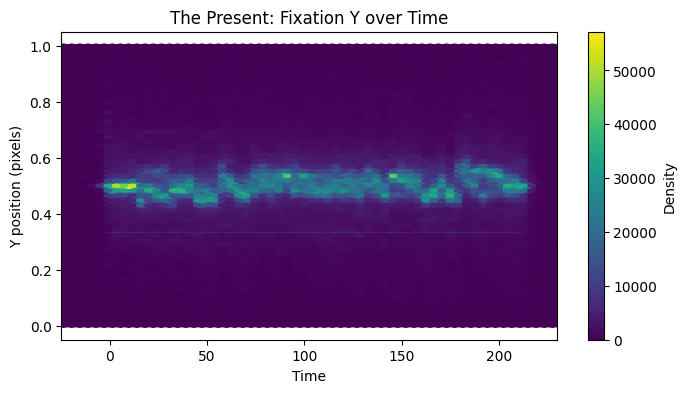

In [45]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_combined_df['times'],
    present_combined_df['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlim(-25, 230)
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('The Present: Fixation Y over Time')

plt.show()

## *Sherlock* DS1

In [22]:
### read in data 
sherlock_df = pd.read_csv("sherlock_ds1_df.csv")
sherlock_df = sherlock_df.iloc[:, 1:]
print(sherlock_df.head())
print(sherlock_df.shape)

   x_corr_pixels  y_corr_pixels     times      subjectID
0          669.9          513.0 -0.405907  sub-A00010201
1          669.9          512.3 -0.400351  sub-A00010201
2          670.0          511.9 -0.394795  sub-A00010201
3          670.1          511.2 -0.389240  sub-A00010201
4          670.0          510.8 -0.383684  sub-A00010201
(20762676, 4)


In [23]:
### descriptive stats 
sherlock_number_subjects = len(sherlock_df['subjectID'].unique())
print(f"Number of subjects in SHERLOCK: {sherlock_number_subjects}")

xx = descr_stats(sherlock_df, 'x_corr_pixels')
print("*"*10)
yy = descr_stats(sherlock_df, 'y_corr_pixels')

Number of subjects in SHERLOCK: 192
Summary stats for column: x_corr_pixels
mean     631.713533
min    -3213.200000
max     3210.400000
std      128.220123
Name: x_corr_pixels, dtype: float64
**********
Summary stats for column: y_corr_pixels
mean     400.642350
min    -3276.700000
max     3276.700000
std      215.704618
Name: y_corr_pixels, dtype: float64


In [24]:
records = []

for subj, grp in sherlock_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["x_corr_pixels"].values
    y     = grp["y_corr_pixels"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["x_corr_pixels", "y_corr_pixels"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: SHERLOCK data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

Summary stats for column: sample_rate_hz
mean    176.897396
min      55.700000
max     180.000000
std      14.797224
Name: sample_rate_hz, dtype: float64
Summary stats for column: x_min
mean    -153.439583
min    -3213.200000
max      531.700000
std      490.474895
Name: x_min, dtype: float64
Summary stats for column: y_min
mean    -689.075521
min    -3276.700000
max      556.000000
std     1206.663623
Name: y_min, dtype: float64
unique sampling rate in sample: [179.3, 180.0, 122.7, 156.3, 179.0, 147.4, 145.8, 179.6, 155.8, 150.0, 151.1, 151.6, 56.9, 176.7, 55.7, 124.7, 151.9, 179.8]


### *Sherlock* FILTERED

In [25]:
### sherlock
# x
sherlock_mean_x = sherlock_df['x_corr_pixels'].mean()
sherlock_sd_x = sherlock_df['x_corr_pixels'].std()
print(f"sherlock x_corr mean: {sherlock_mean_x} and std: {sherlock_sd_x}")
sherlock_upper_x = sherlock_mean_x + (sherlock_sd_x*2.5)
sherlock_lower_x = sherlock_mean_x - (sherlock_sd_x*2.5)
print(f"sherlock x_corr upper: {sherlock_upper_x} and lower: {sherlock_lower_x}")
print(f"sherlock x_corr min x: {sherlock_df['x_corr_pixels'].min()} and max x: {sherlock_df['x_corr_pixels'].max()}")
print(f"sherlock number of samples: {len(sherlock_df)}")

# filter out oultiers 
sherlock_df_filtered = sherlock_df[
    (sherlock_df['x_corr_pixels'] <= sherlock_upper_x) &
    (sherlock_df['x_corr_pixels'] >= sherlock_lower_x)
]
print(f"Filter sherlock mean x: {sherlock_df_filtered['x_corr_pixels'].mean()}, x_min: {sherlock_df_filtered['x_corr_pixels'].min()}, x_max: {sherlock_df_filtered['x_corr_pixels'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")

print("*"*50)

# y 
sherlock_mean_y = sherlock_df['y_corr_pixels'].mean()
sherlock_sd_y = sherlock_df['y_corr_pixels'].std()
print(f"sherlock y_corr mean: {sherlock_mean_y} and std: {sherlock_sd_y}")
sherlock_upper_y = sherlock_mean_y + (sherlock_sd_y*2.5)
sherlock_lower_y = sherlock_mean_y - (sherlock_sd_y*2.5)
print(f"sherlock y_corr upper: {sherlock_upper_y} and lower: {sherlock_lower_y}")
print(f"sherlock y_corr min y: {sherlock_df['y_corr_pixels'].min()} and max y: {sherlock_df['y_corr_pixels'].max()}")

# filter out outliers 
sherlock_df_filtered = sherlock_df_filtered[
    (sherlock_df_filtered['y_corr_pixels'] <= sherlock_upper_y) &
    (sherlock_df_filtered['y_corr_pixels'] >= sherlock_lower_y)
]
print(f"Filtered sherlock mean y: {sherlock_df_filtered['y_corr_pixels'].mean()}, y_min: {sherlock_df_filtered['y_corr_pixels'].min()}, y_max: {sherlock_df_filtered['y_corr_pixels'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")
print(f"Filter sherlock number of subjects: {len(sherlock_df['subjectID'].unique())}")

sherlock x_corr mean: 631.713533414479 and std: 128.22012334351132
sherlock x_corr upper: 952.2638417732574 and lower: 311.1632250557007
sherlock x_corr min x: -3213.2 and max x: 3210.4
sherlock number of samples: 20762676
Filter sherlock mean x: 640.4973818277572, x_min: 311.2, x_max: 952.2
Filter sherlock number of samples lost: 536543
**************************************************
sherlock y_corr mean: 400.64234996972453 and std: 215.7046180931074
sherlock y_corr upper: 939.903895202493 and lower: -138.619195263044
sherlock y_corr min y: -3276.7 and max y: 3276.7
Filtered sherlock mean y: 395.54509381764166, y_min: -138.6, y_max: 939.9
Filter sherlock number of samples lost: 814722
Filter sherlock number of subjects: 192


### *Sherlock* STANDARIZED

In [26]:
# sherlock 
sherlock_df_standard = sherlock_df_filtered
x_min_sherlock = sherlock_df_filtered['x_corr_pixels'].min()
x_max_sherlock = sherlock_df_filtered['x_corr_pixels'].max()
sherlock_df_standard['x_norm'] = (sherlock_df_standard['x_corr_pixels'] - x_min_sherlock) / (x_max_sherlock - x_min_sherlock)
x_norm = descr_stats(sherlock_df_standard, 'x_norm')

print("*"*50)

y_min_sherlock = sherlock_df_filtered['y_corr_pixels'].min()
y_max_sherlock = sherlock_df_filtered['y_corr_pixels'].max()
sherlock_df_standard['y_norm'] = (sherlock_df_standard['y_corr_pixels'] - y_min_sherlock) / (y_max_sherlock - y_min_sherlock)
y_norm = descr_stats(sherlock_df_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.516158
min     0.000000
max     1.000000
std     0.128598
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.495267
min     0.000000
max     1.000000
std     0.109302
Name: y_norm, dtype: float64


## *Sherlock* DS2

In [27]:
### read in data 
sherlock_df2 = pd.read_csv("sherlock_ds2_right_eye_df.csv")
sherlock_df2 = sherlock_df2.iloc[:, 1:]
print(sherlock_df2.head())
print(sherlock_df2.shape)

    rightEyeX   rightEyeY     times      subjectID
0  884.000000  529.299988 -1.433650  sub-A00008326
1  895.900024  519.099976 -1.433295  sub-A00008326
2  897.099976  507.399994 -1.431131  sub-A00008326
3  896.400024  507.600006 -1.429064  sub-A00008326
4  896.500000  506.799988 -1.427053  sub-A00008326
(35309166, 4)


In [28]:
### descriptive stats 
sherlock_number_subjects = len(sherlock_df2['subjectID'].unique())
print(f"Number of subjects in SHERLOCK: {sherlock_number_subjects}")

xx = descr_stats(sherlock_df2, 'rightEyeX')
print("*"*10)
yy = descr_stats(sherlock_df2, 'rightEyeY')

Number of subjects in SHERLOCK: 115
Summary stats for column: rightEyeX
mean    -3345.031095
min    -32768.000000
max      2560.000000
std     10809.838243
Name: rightEyeX, dtype: float64
**********
Summary stats for column: rightEyeY
mean    -3488.437897
min    -32768.000000
max      2047.800049
std     10755.604139
Name: rightEyeY, dtype: float64


In [29]:
records = []

for subj, grp in sherlock_df2.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["rightEyeX"].values
    y     = grp["rightEyeY"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["rightEyeX", "rightEyeY"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_17107/2583738579.py:31: RuntimeWarning: divide by zero encountered in divide
  velocity = dist / diffs                        # px/s
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_17107/2583738579.py:31: RuntimeWarning: invalid value encountered in divide
  velocity = dist / diffs                        # px/s
/opt/anaconda3/envs/nki_rockland_paper/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1845: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


Summary stats for column: sample_rate_hz
mean    501.730435
min     354.900000
max     956.500000
std      47.786376
Name: sample_rate_hz, dtype: float64
Summary stats for column: x_min
mean   -32198.121739
min    -32768.000000
max         0.000000
std      4302.320983
Name: x_min, dtype: float64
Summary stats for column: y_min
mean   -32198.121739
min    -32768.000000
max         0.000000
std      4302.320983
Name: y_min, dtype: float64
unique sampling rate in sample: [503.4, 496.2, 506.4, 503.2, 494.1, 506.2, 505.5, 504.0, 498.1, 508.3, 509.2, 502.6, 499.3, 492.1, 501.6, 493.6, 505.9, 500.1, 493.2, 491.7, 503.5, 504.1, 492.5, 505.2, 498.7, 506.6, 501.8, 499.6, 499.2, 502.7, 498.2, 497.0, 492.2, 501.1, 507.4, 503.1, 505.1, 406.6, 508.0, 501.0, 505.8, 505.7, 354.9, 504.4, 502.9, 499.4, 507.0, 358.9, 498.8, 502.4, 496.0, 492.0, 500.5, 497.7, 503.6, 505.0, 499.8, 956.5, 501.4, 500.8, 496.9, 485.9, 492.4, 509.0, 507.5, 497.4, 498.4, 503.9, 493.3, 508.8, 498.3, 490.3, 497.2, 503.0, 498.0, 

### *Sherlock* DS2 FILTERED 

In [30]:
### sherlock
# x
sherlock_mean_x = sherlock_df2['rightEyeX'].mean()
sherlock_sd_x = sherlock_df2['rightEyeX'].std()
print(f"sherlock x_corr mean: {sherlock_mean_x} and std: {sherlock_sd_x}")
sherlock_upper_x = sherlock_mean_x + (sherlock_sd_x*2.5)
sherlock_lower_x = sherlock_mean_x - (sherlock_sd_x*2.5)
print(f"sherlock x_corr upper: {sherlock_upper_x} and lower: {sherlock_lower_x}")
print(f"sherlock x_corr min x: {sherlock_df2['rightEyeX'].min()} and max x: {sherlock_df2['rightEyeX'].max()}")
print(f"sherlock number of samples: {len(sherlock_df2)}")

# filter out oultiers 
sherlock_df2_filtered = sherlock_df2[
    (sherlock_df2['rightEyeX'] <= sherlock_upper_x) &
    (sherlock_df2['rightEyeX'] >= sherlock_lower_x)
]
print(f"Filter sherlock mean x: {sherlock_df2_filtered['rightEyeX'].mean()}, x_min: {sherlock_df2_filtered['rightEyeX'].min()}, x_max: {sherlock_df2_filtered['rightEyeX'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df2)-len(sherlock_df2_filtered)}")

print("*"*50)

# y 
sherlock_mean_y = sherlock_df2['rightEyeY'].mean()
sherlock_sd_y = sherlock_df2['rightEyeY'].std()
print(f"sherlock y_corr mean: {sherlock_mean_y} and std: {sherlock_sd_y}")
sherlock_upper_y = sherlock_mean_y + (sherlock_sd_y*2.5)
sherlock_lower_y = sherlock_mean_y - (sherlock_sd_y*2.5)
print(f"sherlock y_corr upper: {sherlock_upper_y} and lower: {sherlock_lower_y}")
print(f"sherlock y_corr min y: {sherlock_df2['rightEyeY'].min()} and max y: {sherlock_df2['rightEyeY'].max()}")

# filter out outliers 
sherlock_df2_filtered = sherlock_df2_filtered[
    (sherlock_df2_filtered['rightEyeY'] <= sherlock_upper_y) &
    (sherlock_df2_filtered['rightEyeY'] >= sherlock_lower_y)
]
print(f"Filtered sherlock mean y: {sherlock_df2_filtered['rightEyeY'].mean()}, y_min: {sherlock_df2_filtered['rightEyeY'].min()}, y_max: {sherlock_df2_filtered['rightEyeY'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df2)-len(sherlock_df2_filtered)}")
print(f"Filter sherlock number of subjects: {len(sherlock_df2['subjectID'].unique())}")

sherlock x_corr mean: -3345.0310948690626 and std: 10809.838242761169
sherlock x_corr upper: 23679.564512033856 and lower: -30369.626701771984
sherlock x_corr min x: -32768.0 and max x: 2560.0
sherlock number of samples: 35309166
Filter sherlock mean x: 623.9862897855583, x_min: -1279.300048828125, x_max: 2560.0
Filter sherlock number of samples lost: 4196896
**************************************************
sherlock y_corr mean: -3488.437896503501 and std: 10755.604139147972
sherlock y_corr upper: 23400.57245136643 and lower: -30377.44824437343
sherlock y_corr min y: -32768.0 and max y: 2047.800048828125
Filtered sherlock mean y: 461.23459842907783, y_min: -1023.5999755859376, y_max: 2047.800048828125
Filter sherlock number of samples lost: 4196896
Filter sherlock number of subjects: 115


### *Sherlock* DS2 STANDARIZED

In [31]:
# sherlock 
sherlock_df2_standard = sherlock_df2_filtered
x_min_sherlock = sherlock_df2_filtered['rightEyeX'].min()
x_max_sherlock = sherlock_df2_filtered['rightEyeX'].max()
sherlock_df2_standard['x_norm'] = (sherlock_df2_standard['rightEyeX'] - x_min_sherlock) / (x_max_sherlock - x_min_sherlock)
x_norm = descr_stats(sherlock_df2_standard, 'x_norm')

print("*"*50)

y_min_sherlock = sherlock_df2_filtered['rightEyeY'].min()
y_max_sherlock = sherlock_df2_filtered['rightEyeY'].max()
sherlock_df2_standard['y_norm'] = (sherlock_df2_standard['rightEyeY'] - y_min_sherlock) / (y_max_sherlock - y_min_sherlock)
y_norm = descr_stats(sherlock_df2_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.495738
min     0.000000
max     1.000000
std     0.074622
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.483439
min     0.000000
max     1.000000
std     0.067912
Name: y_norm, dtype: float64


## Combine *Sherlock* DS1 and DS2

In [46]:
cols = ['times', 'subjectID', 'x_norm', 'y_norm']
sherlock_df_merge = sherlock_df_standard[cols]
sherlock_df2_merge = sherlock_df2_standard[cols]

sherlock_combined_df = pd.concat([sherlock_df_merge, sherlock_df2_merge])


In [38]:
descr_stats(sherlock_combined_df, 'times')

Summary stats for column: times
mean    302.475802
min     -44.219756
max     839.933215
std     177.093260
Name: times, dtype: float64


mean    302.475802
min     -44.219756
max     839.933215
std     177.093260
Name: times, dtype: float64

## *Sherlock* PLOT

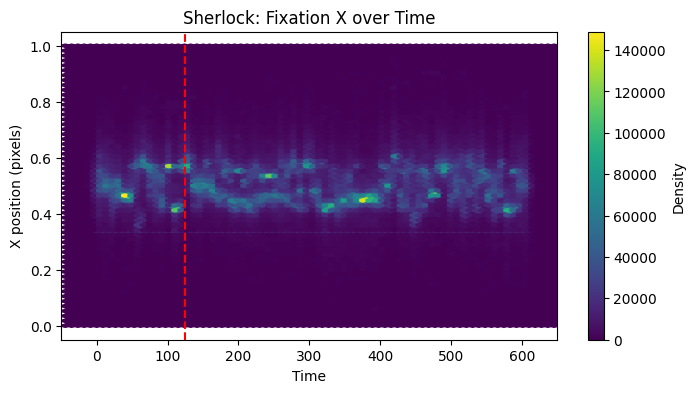

In [48]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_combined_df['times'],
    sherlock_combined_df['x_norm'],
    gridsize=100,
)

# Add lines: 2:04
line_times = [124]

# Add vertical dashed red lines
plt.axvline(x=line_times, color='red', linestyle='--')

plt.colorbar(label='Density')
plt.xlim(-50,650)
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('Sherlock: Fixation X over Time')

plt.show()

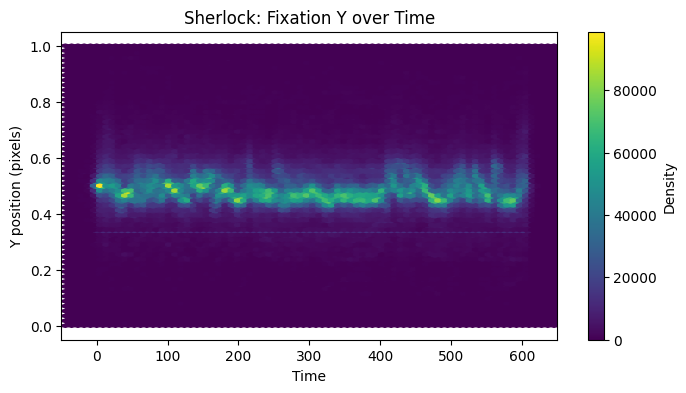

In [49]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_combined_df['times'],
    sherlock_combined_df['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlim(-50,650)
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('Sherlock: Fixation Y over Time')

plt.show()